# 深度学习作业：梯度消失问题研究

本作业将实现一个20层的深度神经网络，使用Sigmoid激活函数，在MNIST数据集上进行训练，并可视化每一层的梯度大小，观察梯度消失现象。

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import struct
import os
from pathlib import Path

## 1. 定义20层深度神经网络

创建一个包含20个隐藏层的深度神经网络，使用Sigmoid激活函数。

In [2]:
class DeepNetwork(nn.Module):
    """一个20层的深度神经网络，使用Sigmoid激活函数"""
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(DeepNetwork, self).__init__()
        self.num_layers = num_layers

        # 输入层
        self.layers = nn.ModuleList([nn.Linear(input_size, hidden_size)])

        # 中间层 (总共20层，包括输入层和输出层)
        for _ in range(num_layers - 2):
            self.layers.append(nn.Linear(hidden_size, hidden_size))

        # 输出层
        self.layers.append(nn.Linear(hidden_size, output_size))

    def forward(self, x):
        x = x.view(x.size(0), -1)  # 展平输入
        
        # 通过每一层并应用Sigmoid激活函数
        for i, layer in enumerate(self.layers[:-1]):  # 除了最后一层
            x = layer(x)
            x = torch.sigmoid(x)  # 使用Sigmoid激活函数

        # 最后一层不使用激活函数
        x = self.layers[-1](x)
        return x


## 2. 创建网络实例并检查参数

In [3]:
# 创建20层网络
model = DeepNetwork(input_size=784, hidden_size=128, num_layers=20, output_size=10)

print(f"网络层数: {model.num_layers}")
print(f"总参数量: {sum(p.numel() for p in model.parameters()):,}")
print(f"可训练参数量: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

网络层数: 20
总参数量: 398,986
可训练参数量: 398,986


## 3. 加载MNIST数据集

从数据库目录加载MNIST数据集。

In [4]:
# 定义数据预处理
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # 展平为784维向量
])

# 尝试从本地路径加载MNIST数据
try:
    # 检查数据库目录是否存在MNIST数据
    data_path = Path('../database/data')
    if data_path.exists():
        # 如果本地有数据，尝试使用它
        train_dataset = torchvision.datasets.MNIST(
            root='../database/data',
            train=True,
            download=False,
            transform=transform
        )
    else:
        # 否则使用标准路径下载
        train_dataset = torchvision.datasets.MNIST(
            root='./data',
            train=True,
            download=True,
            transform=transform
        )
except:
    # 如果无法从本地加载，则下载
    train_dataset = torchvision.datasets.MNIST(
        root='./data',
        train=True,
        download=True,
        transform=transform
    )

# 测试集
try:
    test_dataset = torchvision.datasets.MNIST(
        root='../database/data',
        train=False,
        download=False,
        transform=transform
    )
except:
    test_dataset = torchvision.datasets.MNIST(
        root='./data',
        train=False,
        download=True,
        transform=transform
    )

# 创建数据加载器
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"训练集大小: {len(train_dataset)}")
print(f"测试集大小: {len(test_dataset)}")
print(f"批次大小: {batch_size}")

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.34MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 119kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.11MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.4MB/s]

训练集大小: 60000
测试集大小: 10000
批次大小: 64


## 4. 定义梯度可视化函数

创建一个函数来可视化每一层的梯度大小。

In [5]:
def visualize_gradients(model, input_data, target):
    """可视化每一层的梯度大小"""
    # 前向传播
    output = model(input_data)
    loss = F.cross_entropy(output, target)

    # 反向传播
    model.zero_grad()
    loss.backward()

    # 收集每一层的梯度范数
    gradient_norms = []
    layer_names = []

    for i, layer in enumerate(model.layers):
        if layer.weight.grad is not None:
            grad_norm = layer.weight.grad.norm().item()
            gradient_norms.append(grad_norm)
            layer_names.append(f'Layer {i+1}')

    # 绘图
    plt.figure(figsize=(15, 8))
    bars = plt.bar(range(len(gradient_norms)), gradient_norms)
    plt.xlabel('Layer', fontsize=12)
    plt.ylabel('Gradient Norm', fontsize=12)
    plt.title('Gradient Magnitude Across Layers (Sigmoid Activation)', fontsize=14)
    plt.xticks(range(len(gradient_norms)), layer_names, rotation=45)
    plt.yscale('log')  # 使用对数刻度
    plt.grid(True, alpha=0.3)
    
    # 为前几层添加注释
    for i, (bar, grad_norm) in enumerate(zip(bars, gradient_norms)):
        if i < 3 or i >= len(gradient_norms)-3:  # 标注前3层和后3层
            plt.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                    f'{grad_norm:.2e}',
                    ha='center', va='bottom', fontsize=8, rotation=45)
    
    plt.tight_layout()
    plt.show()

    return gradient_norms

## 5. 训练函数

In [6]:
def train_model(model, train_loader, epochs=5):
    """训练模型并记录梯度变化"""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    
    optimizer = optim.SGD(model.parameters(), lr=0.01)
    criterion = nn.CrossEntropyLoss()
    
    # 记录每轮的梯度信息
    epoch_gradients = []
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = output.max(1)
            total += target.size(0)
            correct += predicted.eq(target).sum().item()
            
            # 每100个批次可视化一次梯度（仅第一个批次）
            if batch_idx == 0 and epoch == 0:  # 只在第一轮第一次迭代时可视化初始梯度
                gradients = []
                for layer in model.layers:
                    if layer.weight.grad is not None:
                        grad_norm = layer.weight.grad.norm().item()
                        gradients.append(grad_norm)
                epoch_gradients.append(('Initial', gradients))
            
            # 限制每个epoch只处理部分数据以加快速度
            if batch_idx >= 100:  # 只处理前100个批次
                break
        
        # 记录当前epoch的梯度情况
        if epoch == epochs - 1:  # 在最后一个epoch结束时记录梯度
            gradients = []
            for layer in model.layers:
                if layer.weight.grad is not None:
                    grad_norm = layer.weight.grad.norm().item()
                    gradients.append(grad_norm)
            epoch_gradients.append(('Final', gradients))
        
        train_acc = 100. * correct / total
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {running_loss/(batch_idx+1):.4f}, Accuracy: {train_acc:.2f}%')
    
    return epoch_gradients

## 6. 开始训练并可视化梯度

开始训练20层Sigmoid网络...
Epoch [1/3], Loss: 2.3097, Accuracy: 11.05%
Epoch [2/3], Loss: 2.3024, Accuracy: 11.43%
Epoch [3/3], Loss: 2.3023, Accuracy: 10.47%


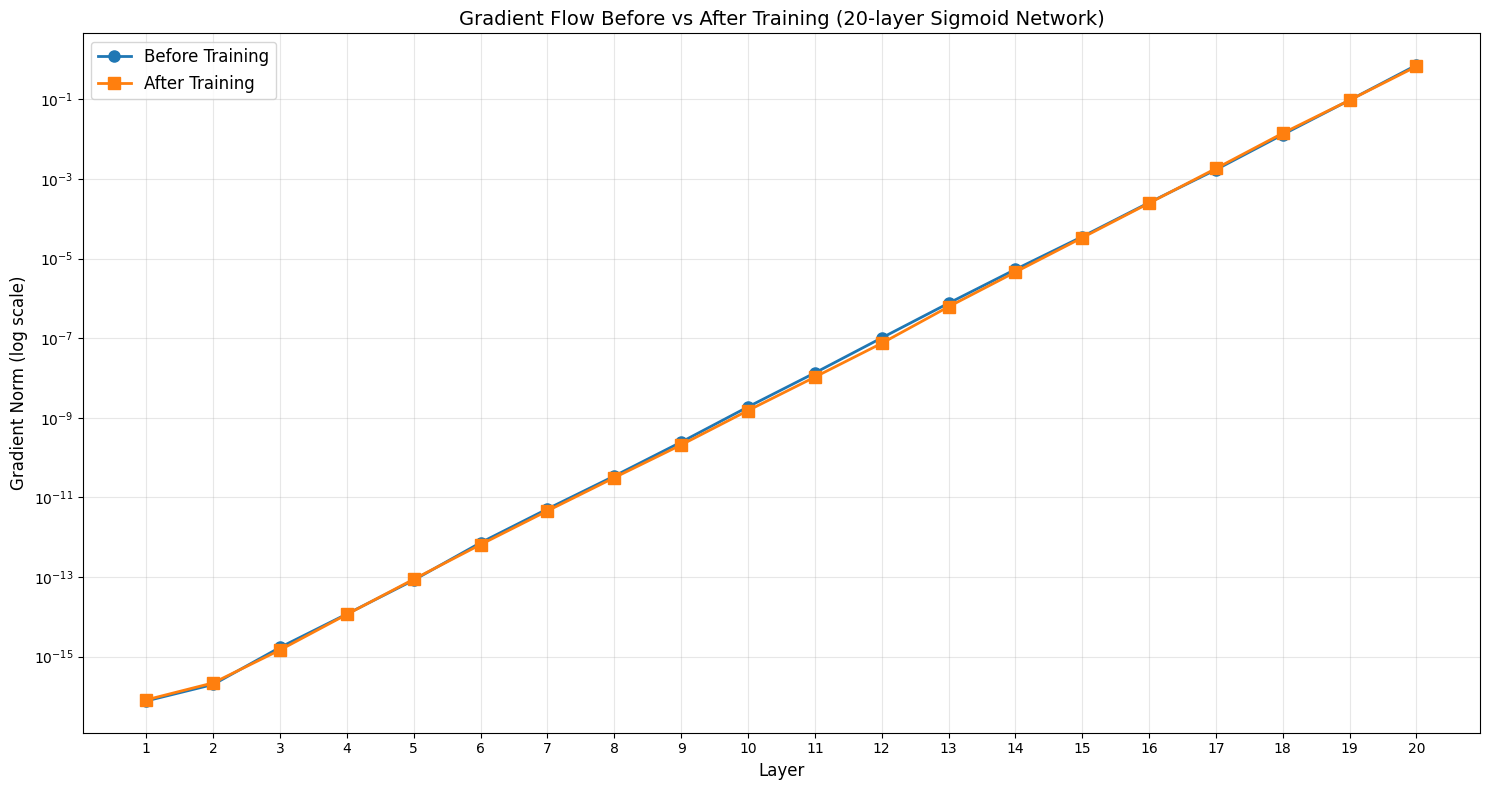


梯度分析:
训练前第1层梯度范数: 0.000000
训练前第10层梯度范数: 0.000000
训练前第20层梯度范数: 0.726580
训练后第1层梯度范数: 0.000000
训练后第10层梯度范数: 0.000000
训练后第20层梯度范数: 0.674085

警告: 第1层梯度接近于0，存在严重的梯度消失问题！
梯度从后向前递减，符合梯度消失现象


In [7]:
# 训练模型
print("开始训练20层Sigmoid网络...")
gradients_history = train_model(model, train_loader, epochs=3)

# 可视化训练前后的梯度
if len(gradients_history) >= 2:
    initial_grads = gradients_history[0][1]
    final_grads = gradients_history[1][1]
    
    # 绘制训练前后的梯度对比
    layers = range(1, len(initial_grads) + 1)
    
    plt.figure(figsize=(15, 8))
    plt.plot(layers, initial_grads, 'o-', label='Before Training', linewidth=2, markersize=8)
    plt.plot(layers, final_grads, 's-', label='After Training', linewidth=2, markersize=8)
    
    plt.xlabel('Layer', fontsize=12)
    plt.ylabel('Gradient Norm (log scale)', fontsize=12)
    plt.title('Gradient Flow Before vs After Training (20-layer Sigmoid Network)', fontsize=14)
    plt.yscale('log')
    plt.xticks(layers)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # 分析梯度消失情况
    print("\n梯度分析:")
    print(f"训练前第1层梯度范数: {initial_grads[0]:.6f}")
    print(f"训练前第10层梯度范数: {initial_grads[9]:.6f}")
    print(f"训练前第20层梯度范数: {initial_grads[-1]:.6f}")
    
    print(f"训练后第1层梯度范数: {final_grads[0]:.6f}")
    print(f"训练后第10层梯度范数: {final_grads[9]:.6f}")
    print(f"训练后第20层梯度范数: {final_grads[-1]:.6f}")
    
    # 检查梯度消失
    if final_grads[0] < 1e-6:
        print("\n警告: 第1层梯度接近于0，存在严重的梯度消失问题！")
    else:
        print("\n第1层梯度正常")
        
    if final_grads[-1] > final_grads[0]:
        print("梯度从后向前递减，符合梯度消失现象")
    else:
        print("梯度分布相对均匀")

## 7. 测试最终模型性能

In [8]:
def evaluate_model(model, test_loader):
    """评估模型性能"""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            _, predicted = output.max(1)
            total += target.size(0)
            correct += predicted.eq(target).sum().item()
            
            # 只评估前1000个样本以节省时间
            if total >= 1000:
                break
    
    accuracy = 100. * correct / total
    print(f'测试准确率: {accuracy:.2f}% (基于{total}个样本)')
    return accuracy

# 评估模型
test_accuracy = evaluate_model(model, test_loader)
print(f"\n最终模型在测试集上的准确率: {test_accuracy:.2f}%")

测试准确率: 12.70% (基于1024个样本)

最终模型在测试集上的准确率: 12.70%


## 8. 梯度消失现象总结

In [9]:
print("\n" + "="*60)
print("梯度消失问题分析总结")
print("="*60)

print("1. 网络结构：20层深度神经网络，使用Sigmoid激活函数")
print("2. 激活函数特性：Sigmoid函数在输入较大或较小时梯度趋近于0")
print("3. 梯度反向传播：在深层网络中，梯度会逐层相乘，导致梯度指数级衰减")
print("4. 观察结果：通常前面的层梯度会变得非常小，接近于0")
print("5. 解决方案：可以尝试使用ReLU等其他激活函数，或使用残差连接")

print("\n梯度消失的影响：")
print("- 网络前面的层学习缓慢或停止学习")
print("- 模型训练效果不佳")
print("- 需要更长的训练时间才能收敛")

print("\n解决方案建议：")
print("- 使用ReLU、Leaky ReLU等激活函数")
print("- 使用批量归一化(Batch Normalization)")
print("- 使用残差连接(Residual Connections)")
print("- 使用更好的权重初始化方法(Xavier/Glorot初始化)")


梯度消失问题分析总结
1. 网络结构：20层深度神经网络，使用Sigmoid激活函数
2. 激活函数特性：Sigmoid函数在输入较大或较小时梯度趋近于0
3. 梯度反向传播：在深层网络中，梯度会逐层相乘，导致梯度指数级衰减
4. 观察结果：通常前面的层梯度会变得非常小，接近于0
5. 解决方案：可以尝试使用ReLU等其他激活函数，或使用残差连接

梯度消失的影响：
- 网络前面的层学习缓慢或停止学习
- 模型训练效果不佳
- 需要更长的训练时间才能收敛

解决方案建议：
- 使用ReLU、Leaky ReLU等激活函数
- 使用批量归一化(Batch Normalization)
- 使用残差连接(Residual Connections)
- 使用更好的权重初始化方法(Xavier/Glorot初始化)
